# 3 · Prostorové kódování výstupu OCR

**Odpovídá sekci 4.2 práce — Strategie 1**, část *Optimalizace prostorového
kódování* (Obrázek 4.2).

OCR vrátí text i s jeho souřadnicemi na stránce. Textový jazykový model ale vidí
jen lineární posloupnost znaků — rozvržení stránky sám nevnímá. Prostorovou
informaci mu proto musíme předat zapsanou v textu.

**Otázka:** Kterým zápisem předat modelu strukturu tabulek co nejsrozumitelněji
a zároveň nejúsporněji?

## Testované formáty

| Formát | Princip |
|---|---|
| **JSON-light** | strukturovaný zápis využívající hierarchii objektů |
| **Markdown** | zápis pomocí formátovacích značek pro tabulky |
| **HTML-like** | vyznačení řádků a bloků párovými značkami |

Zcela čistý text bez značek nebyl do srovnání zařazen — modelu neposkytuje žádné
záchytné body pro správné přiřazení hodnot ke klíčům.

| | |
|---|---|
| **Datová sada** | DS2, 152 faktur s dostupným ground truth |
| **Předzpracování** | fixováno z notebooku `02` (P4 — stupně šedi + potlačení šumu) |
| **Metrika** | F1 skóre na úrovni entit |

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

KOREN = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(KOREN / "experiments"))

from thesis_style import *          # noqa: F403
pouzij_styl()

DATA = KOREN / "experiments" / "data"
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Data:", DATA.relative_to(KOREN))

Data: experiments\data


In [2]:
KOD = DATA / "03_prostorove_kodovani"

# Experiment proběhl ve dvou variantách lišících se tím, kolik stran dokumentu
# se modelu předkládá. Přesnost se mezi nimi prakticky neliší, výrazně se ale
# liší absolutní spotřeba tokenů — proto se hodnotí obě.
lie = pd.read_csv(KOD / "lie_benchmark_full.csv")            # jen první strana
lie_vice = pd.read_csv(KOD / "lie_benchmark_vice_stran.csv")  # více stran

PORADI_LIE = ["HTML", "Markdown", "JSON-light"]
VITEZNY_LIE = "JSON-light"

print(f"formátů                    : {lie.lie_strategy.nunique()}")
print(f"dokumentů (první strana)   : {lie.invoice_idx.nunique()}")
print(f"dokumentů (více stran)     : {lie_vice.invoice_idx.nunique()}")
print(f"měření celkem              : {len(lie) + len(lie_vice)}")

formátů                    : 3
dokumentů (první strana)   : 152
dokumentů (více stran)     : 152
měření celkem              : 912


## 3.1 Přesnost podle formátu a kvality skenu (Obrázek 4.2 v práci)

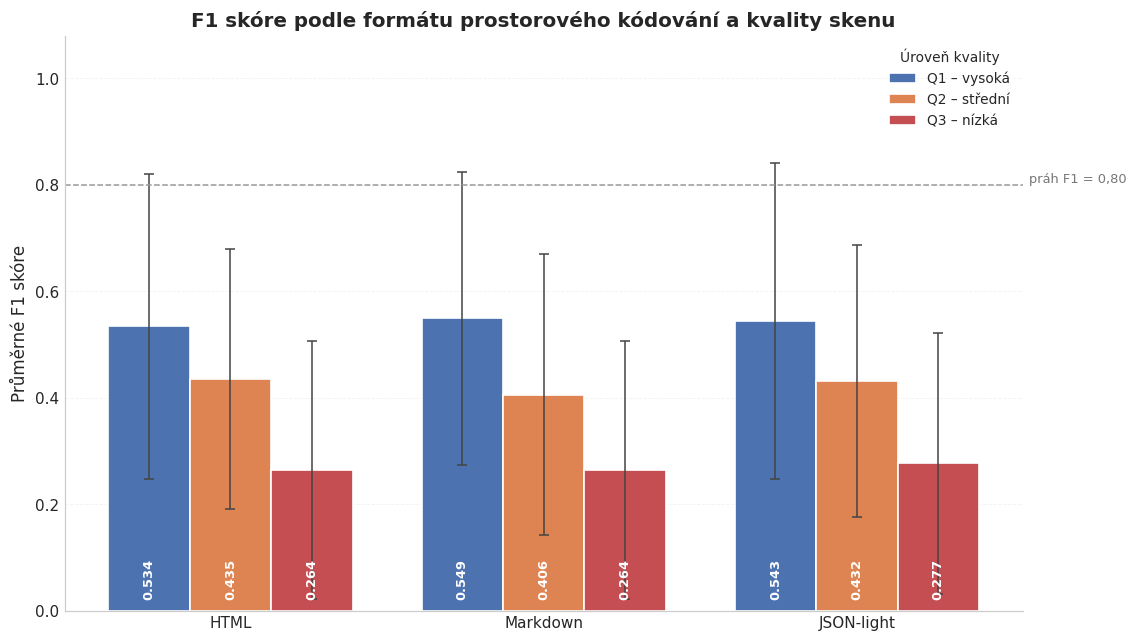

quality,Q1,Q2,Q3
lie_strategy,,,
HTML,0.534,0.435,0.264
Markdown,0.549,0.406,0.264
JSON-light,0.543,0.432,0.277


In [3]:
dle_kvality = (lie.pivot_table(index="lie_strategy", columns="quality",
                               values="f1", aggfunc="mean")
                  .reindex(PORADI_LIE))
smerodatna = (lie.pivot_table(index="lie_strategy", columns="quality",
                              values="f1", aggfunc="std")
                 .reindex(PORADI_LIE))

BARVY_TRID = {"Q1": "#4C72B0", "Q2": "#DD8452", "Q3": "#C44E52"}
NAZVY_TRID = {"Q1": "Q1 – vysoká", "Q2": "Q2 – střední", "Q3": "Q3 – nízká"}

fig, ax = plt.subplots(figsize=(10.5, 6))
x, sirka = np.arange(len(PORADI_LIE)), 0.26
for i, trida in enumerate(["Q1", "Q2", "Q3"]):
    pozice = x + (i - 1) * sirka
    ax.bar(pozice, dle_kvality[trida], sirka, yerr=smerodatna[trida],
           label=NAZVY_TRID[trida], color=BARVY_TRID[trida],
           edgecolor="white", linewidth=1.1,
           error_kw=dict(ecolor="#444444", lw=1.0, capsize=3))
    for px, hodnota in zip(pozice, dle_kvality[trida]):
        ax.text(px, 0.02, f"{hodnota:.3f}", ha="center", va="bottom",
                rotation=90, fontsize=8.5, color="white", fontweight="600")

ax.axhline(0.80, color="#999999", linestyle="--", linewidth=1.0)
ax.text(len(PORADI_LIE) - 0.45, 0.805, "práh F1 = 0,80", fontsize=8.5, color="#777777")
ax.set_xticks(x)
ax.set_xticklabels(PORADI_LIE)
ax.set_ylim(0, 1.08)
uprav_osu(ax, "F1 skóre podle formátu prostorového kódování a kvality skenu",
          y="Průměrné F1 skóre")
ax.legend(title="Úroveň kvality", frameon=False, fontsize=9, title_fontsize=9)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

display(tabulka(dle_kvality.round(3)))

> **Zjištění.** Rozdíly mezi formáty jsou překvapivě malé — v řádu jednotek
> tisícin F1 a menší než směrodatná odchylka mezi jednotlivými fakturami.
> Zásadním faktorem je naopak **kvalita skenu**: u nejhůře čitelných dokumentů
> (Q3) klesá přesnost zhruba na polovinu bez ohledu na použitý formát.

## 3.2 Rozhoduje cena, ne přesnost

Když se formáty přesností neliší, rozhodne spotřeba tokenů — ta se promítá přímo
do ceny každého volání API.

Kolik tokenů se ušetří, závisí na tom, co se počítá a kolik stran dokumentu se
modelu předkládá:

* **délka samotného zápisu OCR** — čistý efekt formátu, HTML platí režii za
  párové značky,
* **tokeny celého promptu** — zahrnují i instrukce, které jsou pro všechny
  formáty stejné, a úsporu tedy ředí,
* **počet stran** — čím víc stran do promptu vstupuje, tím větší podíl promptu
  tvoří zápis OCR a tím víc se úspora projeví.

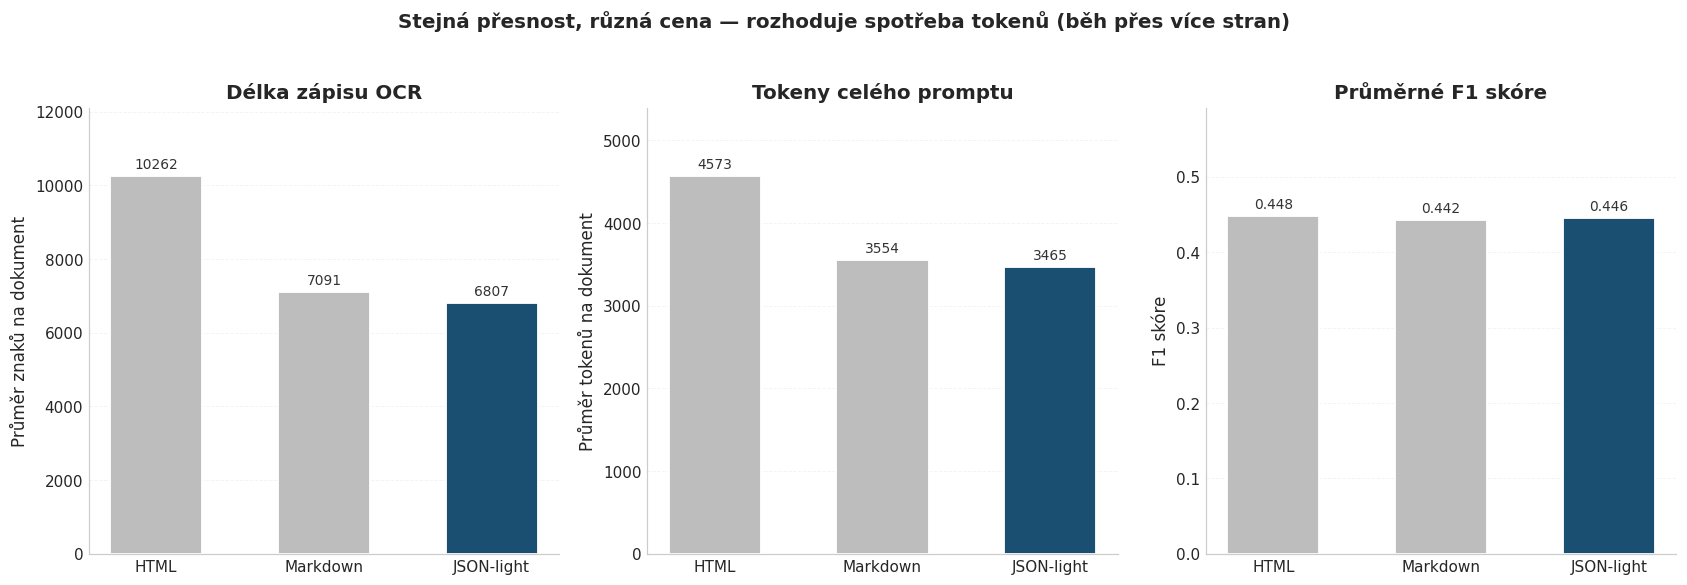

Úspora JSON-light oproti HTML:
  první strana    zápis OCR −35.3 %   ·   celý prompt −19.1 %   (1469 vs 1817 tokenů)
  více stran      zápis OCR −33.7 %   ·   celý prompt −24.2 %   (3465 vs 4573 tokenů)


,F1,prompt_tokeny,delka_zapisu,úspora promptu [%],úspora zápisu [%]
lie_strategy,,,,,
HTML,0.400,4572.800,10262.200,0.000,0.000
Markdown,0.400,3554.000,7090.900,22.300,30.900
JSON-light,0.400,3464.700,6806.900,24.200,33.700


In [4]:
def prehled_nakladu(data: pd.DataFrame) -> pd.DataFrame:
    t = (data.groupby("lie_strategy")
             .agg(F1=("f1", "mean"),
                  prompt_tokeny=("prompt_tokens", "mean"),
                  delka_zapisu=("formatted_len", "mean"),
                  usd_na_dokument=("cost_usd", "mean"))
             .reindex(PORADI_LIE))
    zaklad = t.loc["HTML"]
    t["úspora promptu [%]"] = (1 - t.prompt_tokeny / zaklad.prompt_tokeny) * 100
    t["úspora zápisu [%]"] = (1 - t.delka_zapisu / zaklad.delka_zapisu) * 100
    return t

naklady = prehled_nakladu(lie)
naklady_vice = prehled_nakladu(lie_vice)

fig, osy = plt.subplots(1, 3, figsize=(15.5, 5.2))
barvy = barvy_vitez(PORADI_LIE, vitez=VITEZNY_LIE)

osy[0].bar(PORADI_LIE, naklady_vice.delka_zapisu, color=barvy, width=0.55,
           edgecolor="white", linewidth=1.2)
popisky_sloupcu(osy[0], fmt="{:.0f}")
osy[0].set_ylim(0, naklady_vice.delka_zapisu.max() * 1.18)
uprav_osu(osy[0], "Délka zápisu OCR", y="Průměr znaků na dokument")

osy[1].bar(PORADI_LIE, naklady_vice.prompt_tokeny, color=barvy, width=0.55,
           edgecolor="white", linewidth=1.2)
popisky_sloupcu(osy[1], fmt="{:.0f}")
osy[1].set_ylim(0, naklady_vice.prompt_tokeny.max() * 1.18)
uprav_osu(osy[1], "Tokeny celého promptu", y="Průměr tokenů na dokument")

osy[2].bar(PORADI_LIE, naklady_vice.F1, color=barvy, width=0.55,
           edgecolor="white", linewidth=1.2)
popisky_sloupcu(osy[2], fmt="{:.3f}")
osy[2].set_ylim(0, naklady_vice.F1.max() * 1.32)
uprav_osu(osy[2], "Průměrné F1 skóre", y="F1 skóre")

for ax in osy:
    ax.grid(axis="x", visible=False)

fig.suptitle("Stejná přesnost, různá cena — rozhoduje spotřeba tokenů (běh přes více stran)",
             fontsize=13, fontweight="semibold", y=1.02)
fig.tight_layout()
plt.show()

print("Úspora JSON-light oproti HTML:")
for popis, t in [("první strana", naklady), ("více stran", naklady_vice)]:
    j = t.loc["JSON-light"]
    print(f"  {popis:14}  zápis OCR −{j['úspora zápisu [%]']:.1f} %"
          f"   ·   celý prompt −{j['úspora promptu [%]']:.1f} %"
          f"   ({j.prompt_tokeny:.0f} vs {t.loc['HTML'].prompt_tokeny:.0f} tokenů)")

display(tabulka(naklady_vice[["F1", "prompt_tokeny", "delka_zapisu",
                              "úspora promptu [%]", "úspora zápisu [%]"]].round(1)))

## Závěr

**Zvolený formát: `JSON-light`.**

| Kritérium | Výsledek |
|---|---|
| Přesnost | nejlepší průměr napříč třídami kvality (rozdíly ale nejsou významné) |
| Nejhorší skeny (Q3) | nejvyšší F1 ze všech tří formátů (0,277) |
| Spotřeba tokenů | výrazně nižší než HTML při shodné přesnosti |

Protože se formáty přesností prakticky neliší, rozhodla **hospodárnost**:
JSON-light zapíše tutéž prostorovou informaci podstatně úsporněji než HTML,
u kterého režii navyšují párové značky. Formát se fixuje pro notebooky `04`–`08`
i pro produkční pipeline.